In [1]:
import os
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Tắt cảnh báo để notebook sạch hơn
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị SHAP trong Notebook
shap.initjs()

print("✅ Thư viện đã sẵn sàng!")

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


✅ Thư viện đã sẵn sàng!


In [27]:
# Đường dẫn tới bộ dữ liệu "Finally" chúng ta vừa tạo
DATA_PATH = r"C:\Users\Acer\Desktop\DATN\DATN_AIR_GROARD_BN_2026\data\finally\final_dataset_target_6h.csv"

df = pd.read_csv(DATA_PATH)

# Kiểm tra 5 dòng đầu
print(f"Kích thước tập dữ liệu: {df.shape}")
display(df.head())

# Kiểm tra các cột đang có
print("\nDanh sách các cột:")
print(df.columns.tolist())

Kích thước tập dữ liệu: (364482, 28)


,timestamp,pm25,pm10,co,no2,so2,o3,aod,dust,village,...,aqi_current,hour,hour_sin,hour_cos,aqi_lag1h,aqi_lag3h,aqi_roll3h,aqi_roll6h,aqi_category,target_aqi_6h
0,2024-01-01 01:00:00,44.8,66.6,676.0,29.0,27.6,36.0,0.38,0.0,Châm Khê,...,89.767068,1,0.258819,0.965926,84.060241,NaN,84.060241,84.060241,Bình thường,105.260870
1,2024-01-01 02:00:00,48.9,72.2,734.0,29.5,27.2,31.0,0.40,0.0,Châm Khê,...,97.835341,2,0.500000,0.866025,89.767068,NaN,86.913655,86.913655,Bình thường,113.127090
2,2024-01-01 03:00:00,53.8,78.9,805.0,30.1,27.3,25.0,0.40,0.0,Châm Khê,...,107.063545,3,0.707107,0.707107,97.835341,84.060241,90.554217,90.554217,Kém,97.638554
3,2024-01-01 04:00:00,58.3,85.0,859.0,30.6,27.8,21.0,0.40,0.0,Châm Khê,...,114.438127,4,0.866025,0.500000,107.063545,89.767068,98.221985,94.681549,Kém,94.293173
4,2024-01-01 05:00:00,57.2,83.1,897.0,31.6,28.6,17.0,0.37,0.0,Châm Khê,...,112.635452,5,0.965926,0.258819,114.438127,97.835341,106.445671,98.632865,Kém,87.602410



Danh sách các cột:
['timestamp', 'pm25', 'pm10', 'co', 'no2', 'so2', 'o3', 'aod', 'dust', 'village', 'temperature', 'humidity', 'wind_speed', 'wind_dir', 'precipitation', 'pressure', 'cloud_cover', 'visibility', 'aqi_current', 'hour', 'hour_sin', 'hour_cos', 'aqi_lag1h', 'aqi_lag3h', 'aqi_roll3h', 'aqi_roll6h', 'aqi_category', 'target_aqi_6h']


In [28]:
# Định nghĩa các cột loại bỏ (không đưa vào training)
# Ta loại bỏ các cột định danh và cột target gốc
drop_cols = ['timestamp', 'village','aqi_current','aqi_roll6h', 'aqi_category', 'target_aqi_6h']

X = df.drop(columns=drop_cols)
y = df['target_aqi_6h']

# Split dữ liệu theo thời gian (shuffle=False) để dự báo tương lai
# 80% để học, 20% để kiểm tra
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

print(f"Số lượng đặc trưng (Features): {X_train.shape[1]}")
print(f"Dữ liệu huấn luyện: {X_train.shape[0]} mẫu")
print(f"Dữ liệu kiểm tra: {X_test.shape[0]} mẫu")

Số lượng đặc trưng (Features): 22
Dữ liệu huấn luyện: 291585 mẫu
Dữ liệu kiểm tra: 72897 mẫu


In [29]:
# Cấu hình tham số cho bài toán Regression
model = xgb.XGBRegressor(
    n_estimators=500,          # Giảm số lượng cây xuống
    learning_rate=0.01,        # Giảm tốc độ học để học chậm và kỹ hơn
    max_depth=4,               # Giảm độ sâu của cây (Rất quan trọng để tránh overfitting)
    subsample=0.7,             
    colsample_bytree=0.7,
    # Thêm các tham số ràng buộc (Regularization)
    reg_alpha=10,              # L1 regularization
    reg_lambda=10,             # L2 regularization
    early_stopping_rounds=30,
    random_state=42,
    tree_method='hist'
)

# Huấn luyện kèm theo bộ Validation để tránh Overfitting
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

print("\n✅ Huấn luyện mô hình hoàn tất!")

[0]	validation_0-rmse:98.17766
[100]	validation_0-rmse:46.24023
[200]	validation_0-rmse:31.11660
[300]	validation_0-rmse:27.04633
[400]	validation_0-rmse:25.67664
[499]	validation_0-rmse:24.97520

✅ Huấn luyện mô hình hoàn tất!


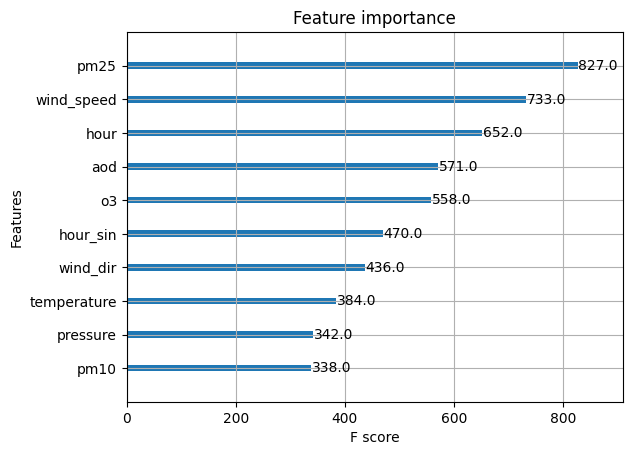

In [30]:
# Xem độ quan trọng của các đặc trưng
import matplotlib.pyplot as plt
xgb.plot_importance(model, max_num_features=10, importance_type='weight')
plt.show()

--- 🛡️ ĐANG ĐÁNH GIÁ VỚI TIME SERIES CROSS-VALIDATION ---
Fold 1: MAE = 13.17, RMSE = 17.75, R2 = 0.8285
Fold 2: MAE = 11.89, RMSE = 15.76, R2 = 0.8713
Fold 3: MAE = 11.56, RMSE = 15.30, R2 = 0.8787
Fold 4: MAE = 11.60, RMSE = 15.33, R2 = 0.8782
Fold 5: MAE = 11.54, RMSE = 15.28, R2 = 0.8791

📊 KẾT QUẢ TRUNG BÌNH CUỐI CÙNG
MAE:  11.95
RMSE: 15.88
R2 Score: 0.8672


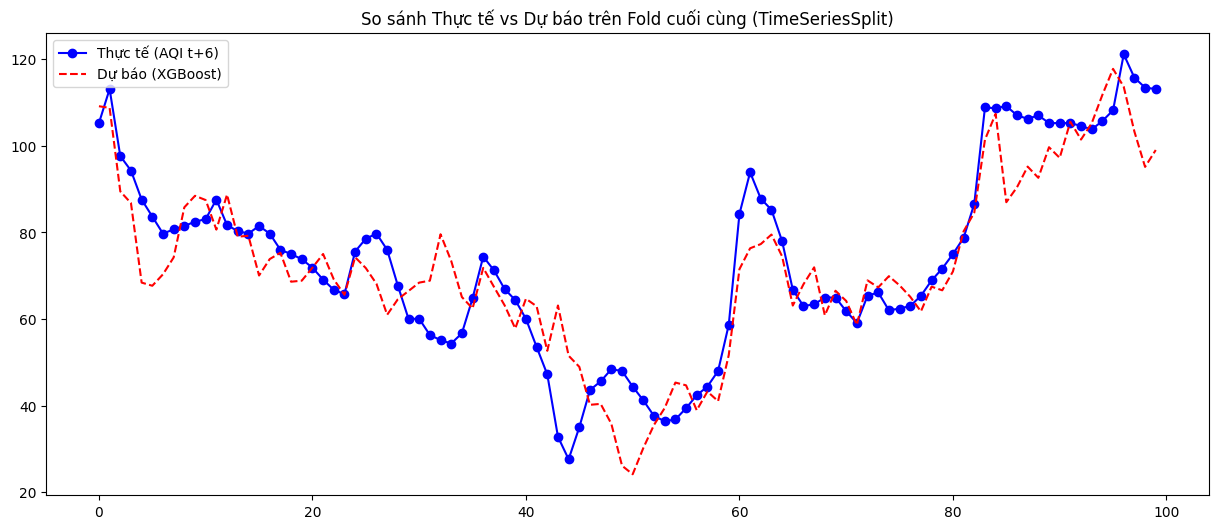

In [31]:
from sklearn.model_selection import TimeSeriesSplit

# 1. Khởi tạo TimeSeriesSplit (5 folds)
tscv = TimeSeriesSplit(n_splits=5)

# Danh sách lưu kết quả
mae_scores = []
rmse_scores = []
r2_scores = []

print("--- 🛡️ ĐANG ĐÁNH GIÁ VỚI TIME SERIES CROSS-VALIDATION ---")

# 2. Vòng lặp Cross-Validation
# Chúng ta sử dụng toàn bộ X, y để chia theo thời gian
for fold, (train_index, test_index) in enumerate(tscv.split(X)):
    # Chia dữ liệu theo chỉ số của Fold
    X_train_cv, X_test_cv = X.iloc[train_index], X.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]
    
    # Huấn luyện mô hình (sử dụng các tham số tối ưu bạn đã chọn)
    model_cv = xgb.XGBRegressor(
        n_estimators=500, 
        learning_rate=0.05, 
        max_depth=6, 
        random_state=42,
        tree_method='hist'
    )
    
    model_cv.fit(X_train_cv, y_train_cv)
    
    # Dự báo trên tập kiểm tra của Fold này
    preds = model_cv.predict(X_test_cv)
    
    # Tính toán chỉ số
    mae = mean_absolute_error(y_test_cv, preds)
    rmse = np.sqrt(mean_squared_error(y_test_cv, preds))
    r2 = r2_score(y_test_cv, preds)
    
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)
    
    print(f"Fold {fold+1}: MAE = {mae:.2f}, RMSE = {rmse:.2f}, R2 = {r2:.4f}")

# 3. Tổng kết kết quả trung bình
print("\n" + "="*40)
print(f"📊 KẾT QUẢ TRUNG BÌNH CUỐI CÙNG")
print(f"MAE:  {np.mean(mae_scores):.2f}")
print(f"RMSE: {np.mean(rmse_scores):.2f}")
print(f"R2 Score: {np.mean(r2_scores):.4f}")
print("="*40)

# Vẽ biểu đồ kết quả của Fold cuối cùng để trực quan hóa
plt.figure(figsize=(15, 6))
plt.plot(y_test_cv.values[:100], label='Thực tế (AQI t+6)', color='blue', marker='o')
plt.plot(preds[:100], label='Dự báo (XGBoost)', color='red', linestyle='--')
plt.title("So sánh Thực tế vs Dự báo trên Fold cuối cùng (TimeSeriesSplit)")
plt.legend()
plt.show()

📊 Biểu đồ SHAP Summary (Mức độ quan trọng của đặc trưng):


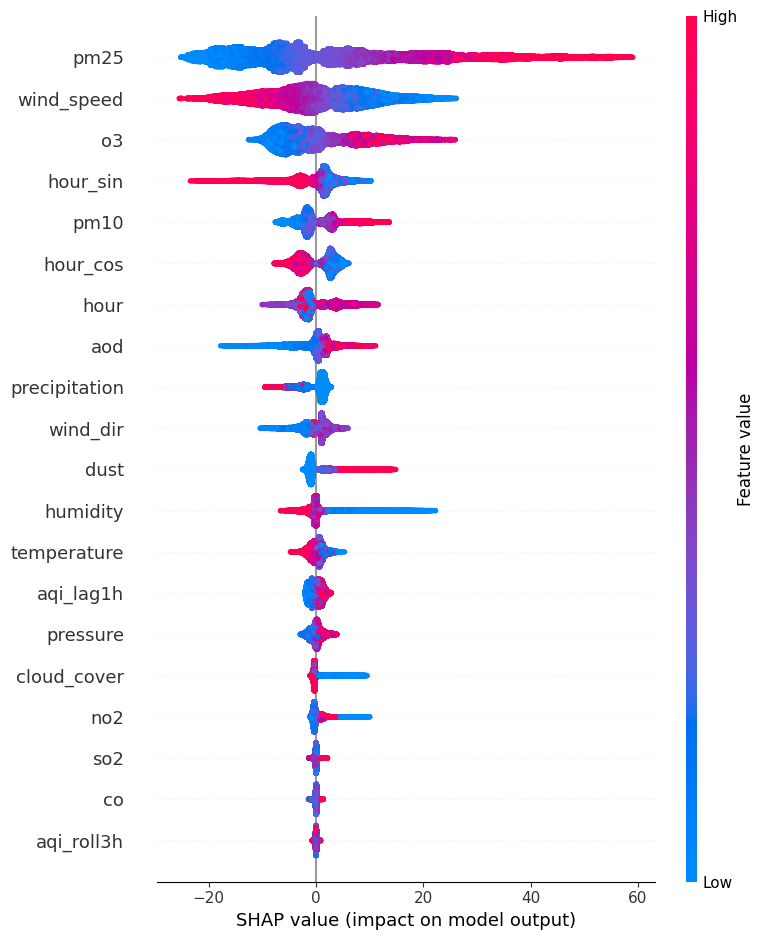

In [32]:
# Tính toán giá trị SHAP cho tập Test
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Vẽ biểu đồ Summary Plot để xem các Features nào ảnh hưởng nhất đến AQI 6h tới
print("📊 Biểu đồ SHAP Summary (Mức độ quan trọng của đặc trưng):")
shap.summary_plot(shap_values, X_test)

Lý giải dự báo cho dòng thứ 10 trong tập Test:


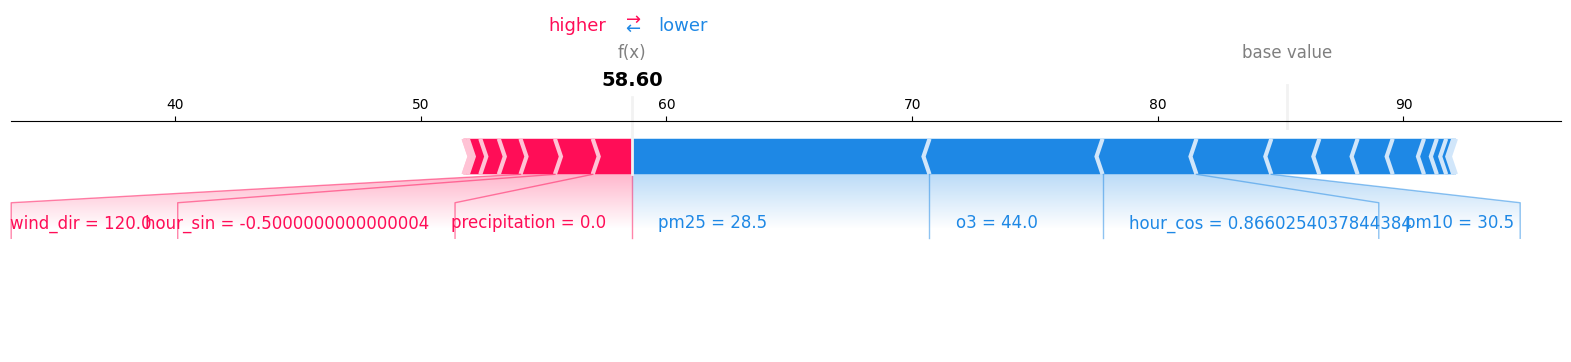

In [33]:
# Chọn 1 dòng ngẫu nhiên trong tập Test để giải thích
sample_idx = 10
print(f"Lý giải dự báo cho dòng thứ {sample_idx} trong tập Test:")

shap.force_plot(
    explainer.expected_value, 
    shap_values[sample_idx,:], 
    X_test.iloc[sample_idx,:],
    matplotlib=True
)

In [34]:
SAVE_PATH = r"C:\Users\Acer\Desktop\DATN\DATN_AIR_GROARD_BN_2026\models\xgboost"
os.makedirs(SAVE_PATH, exist_ok=True)

# Lưu model
joblib.dump(model, os.path.join(SAVE_PATH, "xgboost_aqi_6h.pkl"))

# Lưu danh sách features để dùng cho file Predict/Web sau này
import json
with open(os.path.join(SAVE_PATH, "features.json"), "w") as f:
    json.dump(X.columns.tolist(), f)

print(f"🚀 Model đã được lưu tại: {SAVE_PATH}")

🚀 Model đã được lưu tại: C:\Users\Acer\Desktop\DATN\DATN_AIR_GROARD_BN_2026\models\xgboost
